## Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score

import hdbscan
import umap

import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import random

import sys
import os
from pathlib import Path

# Add src/ to path (once, so imports work)
sys.path.append(str(Path().resolve().parent / "src"))

from paths import DATA_DATASETS, DATA_EMBEDDINGS, DATA_IMAGES

## Load Data

In [2]:
outfits = pd.read_csv(DATA_DATASETS / "outfits.csv", sep=";")
embeddings = pd.read_csv(DATA_EMBEDDINGS / "embeddings_voyage_multimodal.csv", sep=";")
transactions = pd.read_csv(DATA_DATASETS / "transactions.csv", sep=";")

Join dataframes

In [3]:
data = outfits.merge(embeddings, left_on="id", right_on="outfit_id")

In [4]:
data.head()

,id,name,description,group,owner,timeCreated,retailPrice,pricePerWeek,pricePerMonth,Brand,...,dim_2038,dim_2039,dim_2040,dim_2041,dim_2042,dim_2043,dim_2044,dim_2045,dim_2046,dim_2047
0,outfit.fffdaa715c3646f8b1c0f04d549ff07e,Out of stock - Asymmetric Frilled Dress,"This fun, short dress features and asymmetric ...",group.50a586c78eb7626e294ba3bd07d12c79,o_00053,2017-12-30T11:28:01.000000,4000.0,600.0,1200.0,Sandro,...,0.029541,0.010559,0.011230,0.043945,0.035889,-0.015442,-0.001434,0.020630,0.026001,-0.020752
1,outfit.fffa1b9a3db6415d806f3c48f8ab58d9,Yellow Shell Mellomholmene Blouse,This beautiful blouse features an adjustable n...,group.61ad2fcabb3e9197e3836376e6b67f2c,o_00577,2021-06-07T12:07:22.921000,1300.0,590.0,1180.0,ILAG,...,0.012512,-0.005463,-0.000084,-0.006500,0.021362,-0.012939,0.011719,0.023438,0.032715,0.000610
2,outfit.fff175b13ceb453f9928625491412ede,Kaula Dress Black,Kaula from Rodebjer is a fitted dress made in ...,group.37c2b59d63d3a9c2d58e07f532f71f7f,o_00336,2023-06-05T09:17:59.004000,3100.0,930.0,1860.0,Rodebjer,...,0.031982,-0.015442,0.019409,0.034424,0.040771,-0.010620,0.004395,0.018433,0.046387,-0.027832
3,outfit.ffef9d7c292a48b69076d2df2e32352f,For sale - Jarvis Blouse,This wrap blouse has mid length sleeves and a ...,group.dfcaa57546b0b7a5e9eb204449b6cc1c,o_00030,2021-05-18T14:02:28.690000,1500.0,590.0,1180.0,Stylein,...,0.027954,0.017578,-0.001930,0.023804,-0.018677,-0.025146,-0.026367,0.020386,0.035400,0.018433
4,outfit.ffeef842238f4dbdabc6c730a75aa2bd,Black Amber Pants,"Feel slack and nice dressed with this pant, ma...",group.ee297c977905eb21a123a4aea5fbb6d2,o_00602,2021-07-16T14:02:30.643000,1200.0,590.0,1180.0,Kupong knit.wear,...,-0.006805,-0.021973,0.047607,0.013245,0.059082,-0.012878,-0.005249,-0.016724,-0.005676,0.003510


Get embedding-matrix from dataframe

In [4]:
embedding_cols = [col for col in data.columns if col.startswith("dim_")]
X = data[embedding_cols].values

In [6]:
print(np.min(X))
print(np.max(X))

-0.109375
0.125


Scaling enforces same vector length, which should stabilize semantic vectors (should try without later to check if necessary)

In [6]:
X_scaled = normalize(X)

In [7]:
print(np.min(X_scaled))
print(np.max(X_scaled))

-0.10925365915487865
0.12502719919796493


## DBSCAN

In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=30, metric='euclidean')
labels = clusterer.fit_predict(X_scaled)

In [ ]:
np.unique(labels)

array([-1,  0,  1,  2,  3,  4])

In [ ]:
noise_ratio = np.mean(labels == -1)
print("Noise ratio:", noise_ratio)

Noise ratio: 0.14333184229024218


In [ ]:
pd.Series(labels).value_counts()

 3    12988
-1     2243
 2      169
 4      158
 1       52
 0       39
Name: count, dtype: int64

Super dominant cluster (ca. 84%) and 4 relatively small clusters. Noise is fine.

In [ ]:
clusterer_200 = hdbscan.HDBSCAN(min_cluster_size=200, metric='euclidean')
labels_200 = clusterer_200.fit_predict(X_scaled)

In [ ]:
np.unique(labels_200)

noise_ratio = np.mean(labels_200 == -1)
print("Noise ratio:", noise_ratio)

pd.Series(labels_200).value_counts()

Noise ratio: 0.8212026327560866


-1    12851
 0     2264
 1      534
Name: count, dtype: int64

**Results/Interpretation:** 

HDBSCAN clustering results in 1 big cluster with multiple small clusters and in another trial in mainly noise. This hints at products being semantically relatively similar with just a few strongly divergent styles, which is not uncommon in fashion catalogs. Since HDBSCAN works with density based clustering this could be the reason why it does not work effectively on the fashion embeddings.

## K-Means

Elbow method to get optimal amount of clusters:

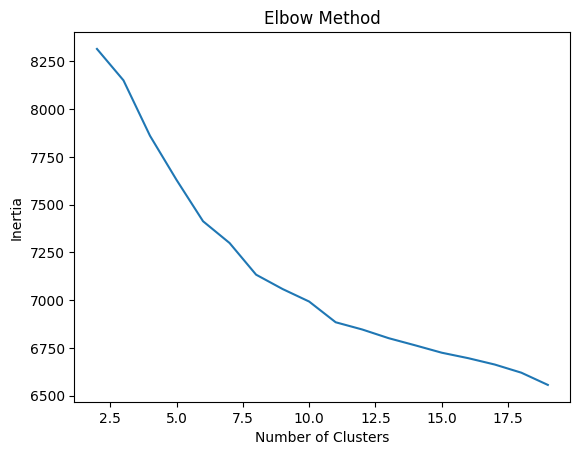

In [13]:
inertia = []
K_range = range(2, 20)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

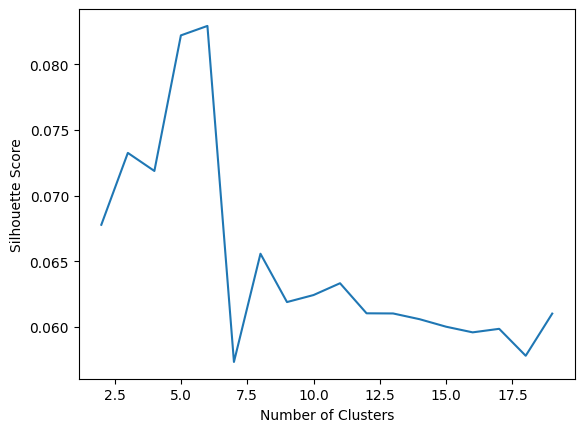

In [14]:
scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.plot(K_range, scores)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [15]:
print("Best K (Elbow):", K_range[np.argmin(inertia)])
print("Best K (Silhouette):", K_range[np.argmax(scores)])

Best K (Elbow): 19
Best K (Silhouette): 6


Use 6 clusters for KMeans 

In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42)
data["cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\JuliusAdmin\AppData\Local\Temp\ipykernel_33332\2454298217.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["cluster"] = kmeans.fit_predict(X_scaled)


In [ ]:
cluster_summary = data.groupby("cluster")["retailPrice"].mean().sort_values()
print(cluster_summary)

cluster
4    1863.511650
1    2080.331376
5    2135.485580
2    2604.987249
6    3053.942869
3    3751.622767
0    4085.612532
Name: retailPrice, dtype: float64


In [ ]:
data["cluster"].value_counts()

cluster
2    3338
6    3031
1    2493
4    2135
3    2045
5    1729
0     878
Name: count, dtype: int64

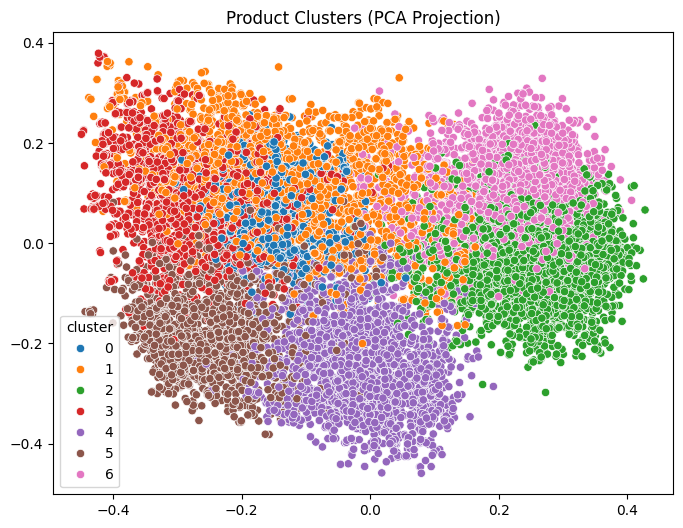

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=data["cluster"], palette="tab10")
plt.title("Product Clusters (PCA Projection)")
plt.show()

In [ ]:
merged = transactions.merge(data[["id", "cluster"]], 
                            left_on="outfit.id", 
                            right_on="id")

cluster_revenue = merged.groupby("cluster").size().sort_values(ascending = False)
print(cluster_revenue)

cluster
2    15983
6    10671
4     8542
3     7490
1     7199
5     6769
0     4303
dtype: int64


## UMAP + KMEANS

Dimension reduction with UMAP. Test if 2048 dimensions is too much to form robust clusters (Curse of dimensionality). 

In [5]:
reducer = umap.UMAP(
    n_components = 20, # reduce to 20 dimensions for clustering
    n_neighbors = 50,
    min_dist = 0.1,
    metric = "cosine",
    random_state = 42 # for reproducibility
)

X_reduced = reducer.fit_transform(X)

c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [6]:
results = []

for k in range(2, 20):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(X_reduced)

    sil_score = silhouette_score(X_reduced, labels)

    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    imbalance = cluster_sizes.std() / cluster_sizes.mean() # relatice imbalance - higher is more imbalanced
    results.append({
        "k": k,
        "silhouette": sil_score,
        "min_cluster_size": cluster_sizes.min(),
        "max_cluster_size": cluster_sizes.max(),
        "imbalance": imbalance
    })

results_df = pd.DataFrame(results)
print(results_df)

     k  silhouette  min_cluster_size  max_cluster_size  imbalance
0    2    0.547607              6630              9019   0.215896
1    3    0.573244               421              8598   0.818173
2    4    0.523904               421              6630   0.687849
3    5    0.553352               323              6630   0.886355
4    6    0.600752               323              6630   0.943307
5    7    0.608660                59              6630   1.090329
6    8    0.644516               323              6623   1.021762
7    9    0.452690               323              3622   0.631229
8   10    0.463004                59              3615   0.740607
9   11    0.465627                59              2564   0.602465
10  12    0.467662                59              2564   0.679283
11  13    0.481700                59              2437   0.712222
12  14    0.484444                15              2437   0.788691
13  15    0.484788                15              2437   0.859708
14  16    

A comprehensive cluster scan revealed a clear global silhouette maximum at K = 8. Beyond K = 8, cluster cohesion dropped substantially and micro-clusters emerged, indicating over-segmentation.

Therefore, K = 8 was selected as the optimal balance between semantic seperation and managerial interpretability. 

Check cluster stability:

In [7]:
aris = []

for seed in range(10):
    k1 = KMeans(n_clusters=8, random_state=seed).fit(X_reduced)
    k2 = KMeans(n_clusters=8, random_state=seed+100).fit(X_reduced)
    
    aris.append(adjusted_rand_score(k1.labels_, k2.labels_))

print("Mean ARI:", np.mean(aris))

Mean ARI: 0.8687157090542776


Cluster robustness was evaluated across multiple random initializations. The mean Adjusted Rand Index (ARI) of 0.87 indicates strong structural stability. Therefore, the 8-cluster solution is both well-separated and reproducible.

In [27]:
k = 8

kmeans = KMeans(n_clusters=k, random_state=42)
data["cluster"] = kmeans.fit_predict(X_reduced)
outfits["cluster"] = data["cluster"]

In [28]:
data["cluster"].value_counts()

cluster
2    6623
1    2168
7    1911
3    1704
5    1409
6    1090
0     421
4     323
Name: count, dtype: int64

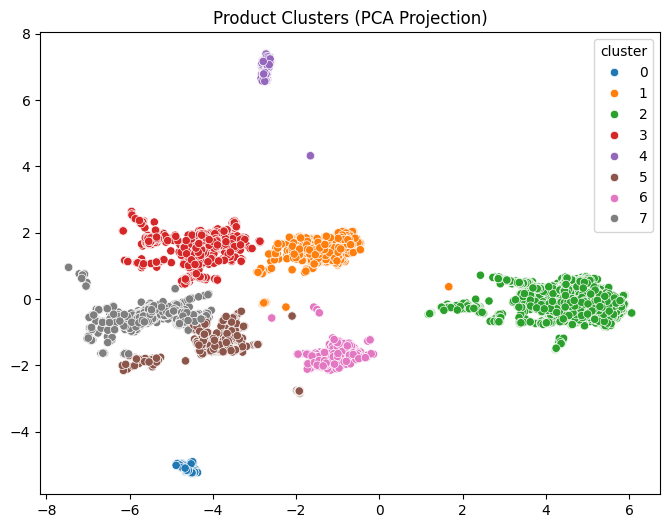

In [29]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_reduced)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=data["cluster"], palette="tab10")
plt.title("Product Clusters (PCA Projection)")
plt.show()

In [30]:
cluster_names = { 0: "Iconic Arm Candy", 1: "Blouses & Shirts", 2: "Dress", 3: "Nordic Comfort", 4: "Golden Hour Details", 5: "Trousers", 6: "Skirts", 7: "Jackets & Coats" }

outfits["cluster_name"] = outfits["cluster"].map(cluster_names)

c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


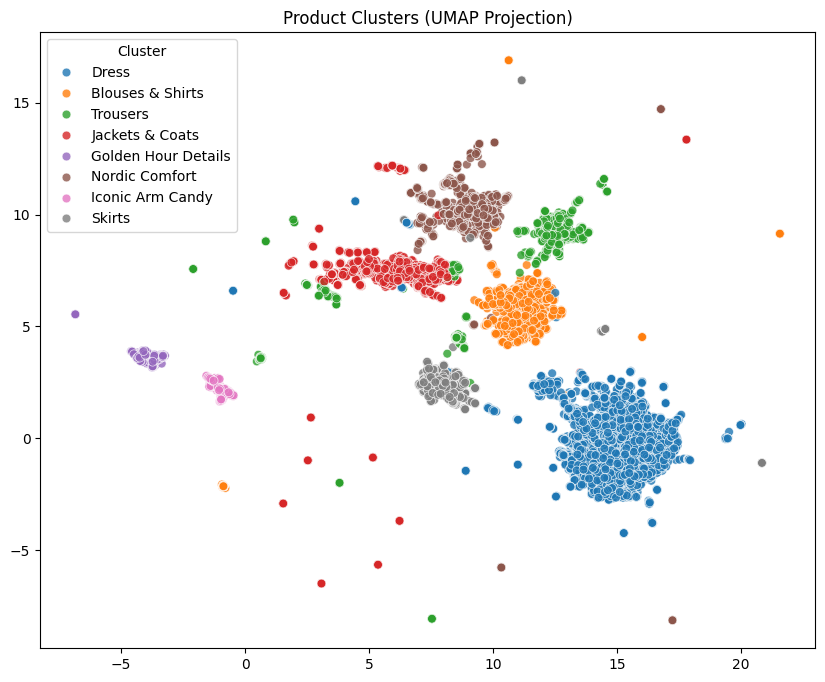

In [31]:
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

X_2d = reducer_2d.fit_transform(X)

plt.figure(figsize=(10,8))
sns.scatterplot(
    x=X_2d[:,0],
    y=X_2d[:,1],
    hue=outfits["cluster_name"],
    palette="tab10",
    s=40,
    alpha=0.8
)

plt.title("Product Clusters (UMAP Projection)")
plt.legend(title="Cluster")
plt.show()

## UMAP + HDBSCAN

Use same dimension reduction from earlier to test if get the same segments.

In [7]:
reducer = umap.UMAP(
    n_components = 20, # reduce to 20 dimensions for clustering
    n_neighbors = 50,
    min_dist = 0.1,
    metric = "cosine",
    random_state = 42 # for reproducibility
)

X_reduced = reducer.fit_transform(X)

c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [8]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=200, metric='euclidean')
labels = clusterer.fit_predict(X_reduced)

data["cluster"] = labels
outfits["cluster"] = data["cluster"]

C:\Users\JuliusAdmin\AppData\Local\Temp\ipykernel_33300\2431344990.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data["cluster"] = labels


In [9]:
print(np.unique(labels))

noise_ratio = np.mean(labels == -1)
print("Noise ratio:", noise_ratio)

pd.Series(labels).value_counts()

[-1  0  1  2  3  4  5  6  7]
Noise ratio: 0.06990862035912838


 7    5854
 3    3111
 4    2041
 5    1519
-1    1094
 2    1080
 1     421
 0     314
 6     215
Name: count, dtype: int64

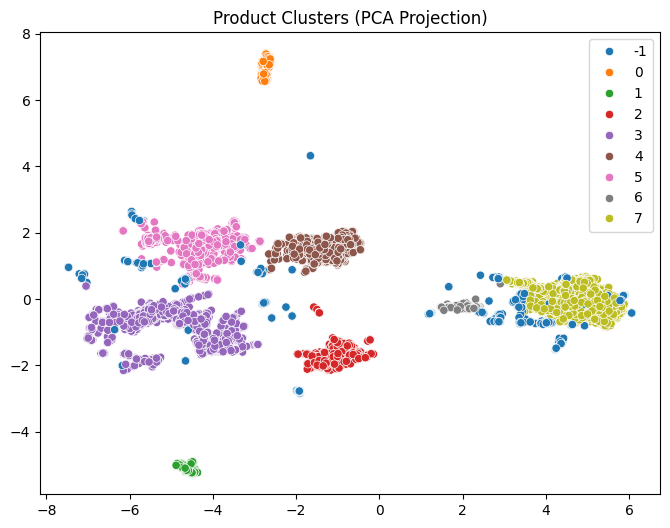

In [10]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_reduced)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=labels, palette="tab10")
plt.title("Product Clusters (PCA Projection)")
plt.show()

In [12]:
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

X_2d = reducer_2d.fit_transform(X)

c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


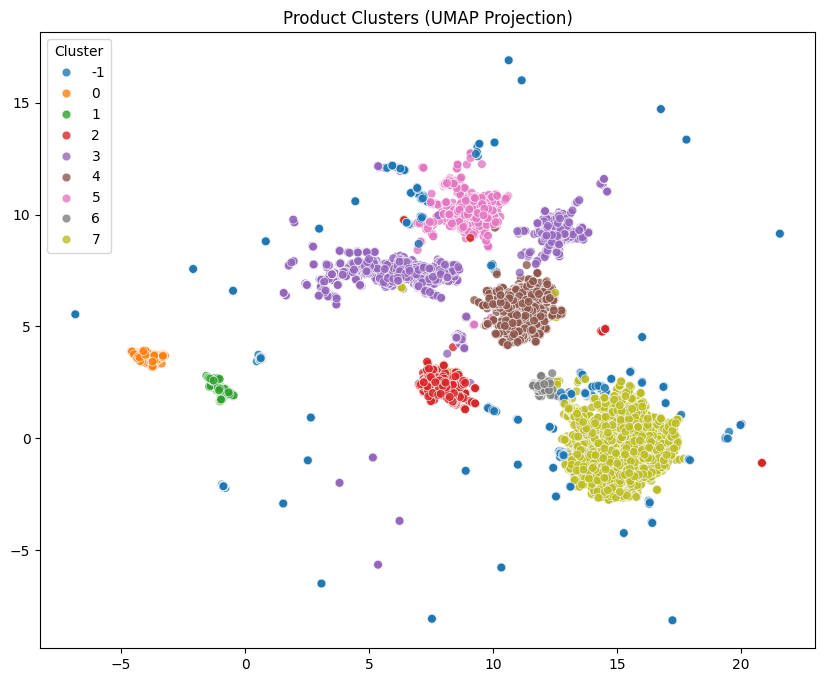

In [13]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    x=X_2d[:,0],
    y=X_2d[:,1],
    hue=labels,
    palette="tab10",
    s=40,
    alpha=0.8
)

plt.title("Product Clusters (UMAP Projection)")
plt.legend(title="Cluster")
plt.show()

**Results**

Fairly similar segmentation. Continuing with KMeans clusters, because HDBSCAN classifies some products as noise so it is harder to interpret those.

## Interpretation of Results

### KMeans

Renaming cluster with actual product category

In [32]:
cluster_names = {

    0: "Iconic Arm Candy",
    1: "Blouses & Shirts",
    2: "Dress",
    3: "Nordic Comfort",
    4: "Golden Hour Details",
    5: "Trousers",
    6: "Skirts",
    7: "Jackets & Coats"
}

In [33]:
outfits["cluster_label"] = outfits["cluster"].map(cluster_names)

outfits[["id", "cluster", "cluster_label"]].head()

,id,cluster,cluster_label
0,outfit.fffdaa715c3646f8b1c0f04d549ff07e,2,Dress
1,outfit.fffa1b9a3db6415d806f3c48f8ab58d9,1,Blouses & Shirts
2,outfit.fff175b13ceb453f9928625491412ede,2,Dress
3,outfit.ffef9d7c292a48b69076d2df2e32352f,1,Blouses & Shirts
4,outfit.ffeef842238f4dbdabc6c730a75aa2bd,5,Trousers


Get 4 pictures of each cluster to check if KMeans segmentation is good.

In [34]:
missing_count = outfits["picture_0"].isna().sum()

print(f"Number of rows without image: {missing_count}")
print(f"Total number of rows: {len(outfits)}")

Number of rows without image: 492
Total number of rows: 15649


In [35]:
def show_cluster_images(outfits_df, cluster_id, img_base_path, n=4, cluster_mapping=None):
    
    cluster_items = outfits_df[outfits_df["cluster"] == cluster_id]

    # Filter out rows without image
    col_name = "picture_0"
    cluster_items = cluster_items.dropna(subset=[col_name])
    
    sample = cluster_items.sample(min(n, len(cluster_items)), random_state=42)
    
    fig, axes = plt.subplots(2, 2, figsize=(3,4))
    axes = axes.flatten()
    
    for ax, (_, row) in zip(axes, sample.iterrows()):
        
        img_path = os.path.join(img_base_path, row["picture_0"])
        
        try:
            img = Image.open(img_path)
            ax.imshow(img)
            #ax.set_title(f'ID: {row["id"]}', fontsize=8)
            ax.axis("off")
        except:
            ax.set_visible(False)

    if cluster_mapping and cluster_id in cluster_mapping:
        title_text = f"{cluster_mapping[cluster_id]}"
    else:
        title_text = f"Cluster {cluster_id}"
    
    plt.suptitle(title_text, fontsize=16)
    plt.tight_layout()
    plt.show()

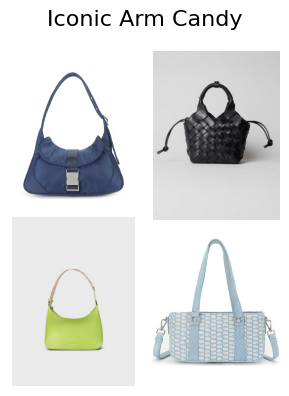

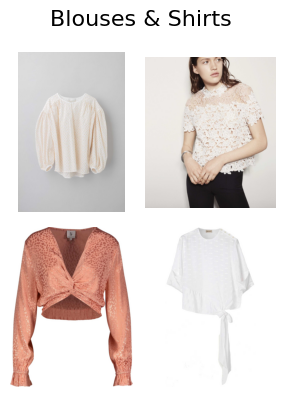

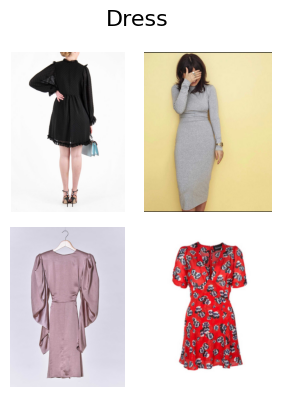

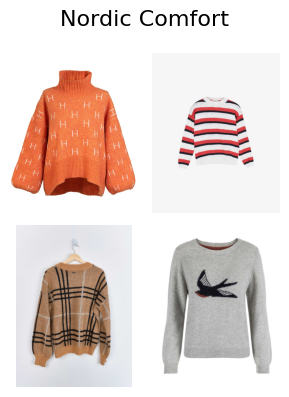

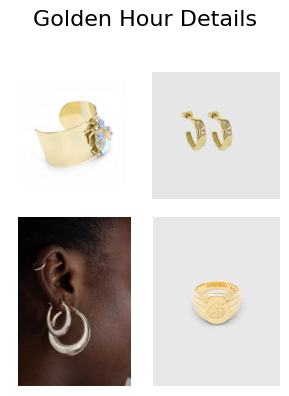

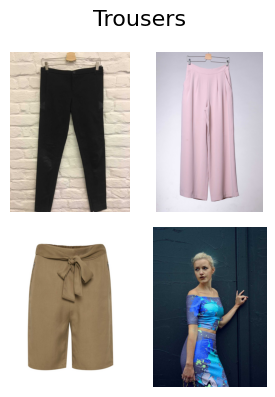

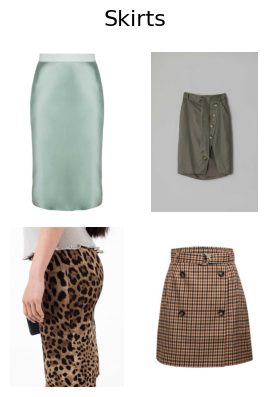

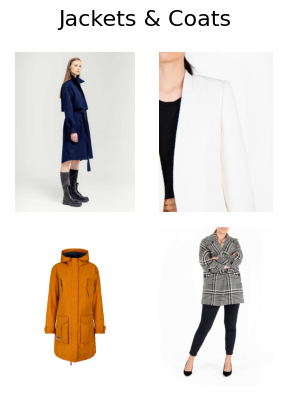

In [36]:
for c in sorted(outfits["cluster"].unique()):
    show_cluster_images(outfits, c, img_base_path=DATA_IMAGES, cluster_mapping=cluster_names)

In [37]:
outfits["Category"].unique()

<StringArray>
[                            'Dresses',                       'Tops, Blouses',
                                'Tops',                  'Knitwear, Trousers',
                             'Blazers',                         'Accessories',
                             'Jewelry',                            'Knitwear',
                            'Trousers',                             'Blouses',
 ...
           'Tops, Sweaters, Cardigans',                   'Blouses, Knitwear',
              'Shirts, Sweaters, Tops',              'Sweaters, Shirts, Tops',
             'Blouses, Sweaters, Tops',                   'Knitwear, Blazers',
                       'Dresses, Tops', 'Cardigans, Knitwear, Sweaters, Tops',
                        'Tops, Skirts',                'Dresses, Accessories']
Length: 119, dtype: str

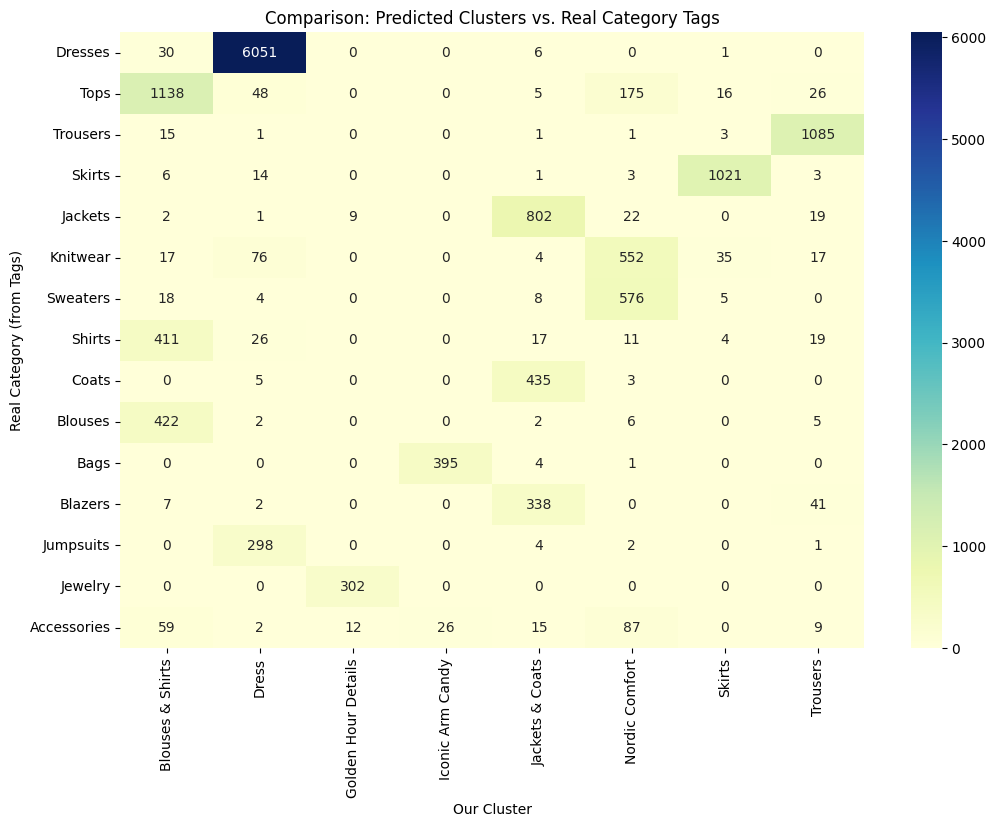

In [38]:
# Extract main category (everything before the first comma)
outfits["main_category"] = outfits["Category"].astype(str).str.split(",").str[0].str.strip()

y_axis = "main_category"
x_axis = "cluster_label"

contingency_table = pd.crosstab(outfits[y_axis], outfits[x_axis])

# Use top 15 categories for better visualization - otherwise too many categories make the heatmap unreadable
top_categories = outfits["main_category"].value_counts().head(15).index
contingency_table = contingency_table.loc[top_categories]

# Visualising with a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap="YlGnBu")
plt.title("Comparison: Predicted Clusters vs. Real Category Tags")
plt.ylabel("Real Category (from Tags)")
plt.xlabel("Our Cluster")
plt.yticks(rotation=0)
plt.show()

### HDBSCAN

Get 4 pictures of each cluster to check if HDBSCAN segmentation is good.

In [14]:
missing_count = outfits["picture_0"].isna().sum()

print(f"Number of rows without image: {missing_count}")
print(f"Total number of rows: {len(outfits)}")

Number of rows without image: 492
Total number of rows: 15649


In [15]:
def show_cluster_images(outfits_df, cluster_id, img_base_path, n=4, cluster_mapping=None):
    
    cluster_items = outfits_df[outfits_df["cluster"] == cluster_id]

    # Filter out rows without image
    col_name = "picture_0"
    cluster_items = cluster_items.dropna(subset=[col_name])
    
    sample = cluster_items.sample(min(n, len(cluster_items)), random_state=42)
    
    fig, axes = plt.subplots(2, 2, figsize=(3,4))
    axes = axes.flatten()
    
    for ax, (_, row) in zip(axes, sample.iterrows()):
        
        img_path = os.path.join(img_base_path, row["picture_0"])
        
        try:
            img = Image.open(img_path)
            ax.imshow(img)
            #ax.set_title(f'ID: {row["id"]}', fontsize=8)
            ax.axis("off")
        except:
            ax.set_visible(False)

    if cluster_mapping and cluster_id in cluster_mapping:
        title_text = f"{cluster_mapping[cluster_id]}"
    else:
        title_text = f"Cluster {cluster_id}"
    
    plt.suptitle(title_text, fontsize=16)
    plt.tight_layout()
    plt.show()

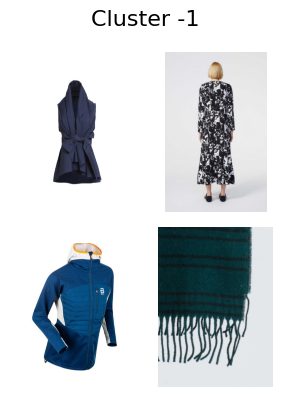

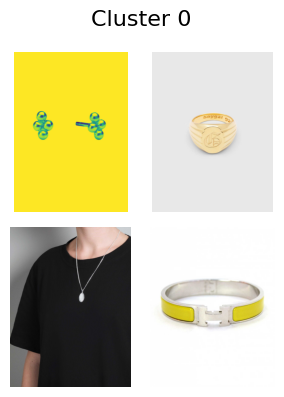

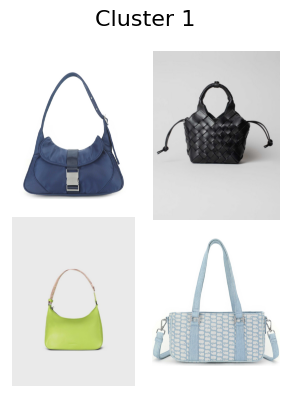

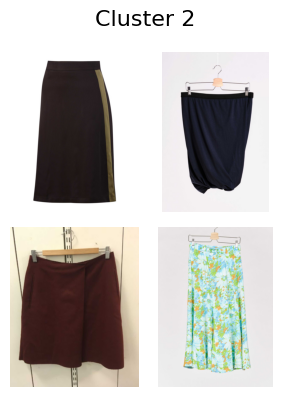

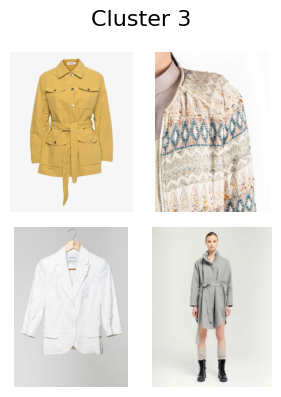

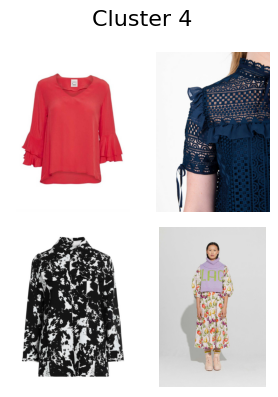

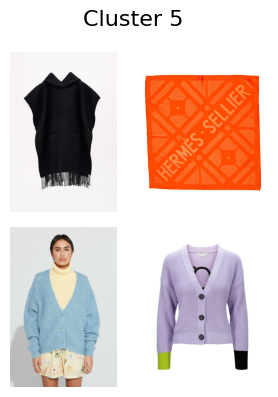

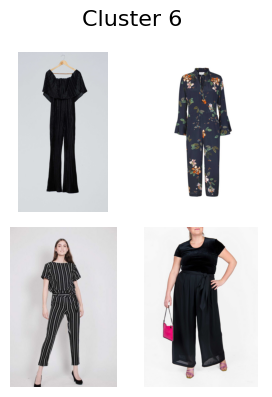

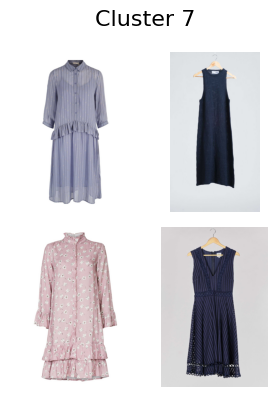

In [16]:
for c in sorted(outfits["cluster"].unique()):
    show_cluster_images(outfits, c, img_base_path=DATA_IMAGES, cluster_mapping=None)

## Business Profiling

### Retail price
Price the rental company has to buy the clothes at

In [39]:
price_profile = outfits.groupby("cluster")["retailPrice"].agg([
    "mean", "median", "min", "max", "count"
]).sort_values("mean", ascending=False)

price_profile.round(2) # Prices are in NOK - 1000 NOK ~ 80 CHF ~ 90 Euro

,mean,median,min,max,count
cluster,,,,,
0,6804.81,4000.0,0.0,52800.0,353
7,3937.86,3200.0,0.0,45000.0,1827
2,2801.97,2400.0,0.0,80000.0,5815
5,2118.70,1725.0,500.0,21000.0,1364
3,2113.63,1900.0,0.0,11500.0,1679
6,2032.77,1700.0,400.0,59400.0,1042
1,1769.23,1500.0,266.0,12500.0,2103
4,1674.18,1500.0,200.0,15000.0,306


### Rental prices for segments 

In [40]:
revenue_profile = pd.DataFrame()

revenue_profile = outfits.groupby("cluster")[["pricePerWeek", "pricePerMonth"]].mean().round(2)
revenue_profile.columns = ["Avg Price per Week", "Avg Price per Month"]

revenue_profile = revenue_profile.sort_values(by="Avg Price per Month", ascending=False)

revenue_profile 

,Avg Price per Week,Avg Price per Month
cluster,,
7,810.87,1605.74
0,743.36,1498.43
3,663.00,1318.78
2,679.36,1306.14
5,635.98,1262.18
1,599.22,1184.15
6,589.17,1156.17
4,562.09,1115.88


In [41]:
revenue_analysis = outfits.groupby("cluster")["pricePerMonth"].agg(["mean", "median", "count"])

revenue_analysis = revenue_analysis.round(2).sort_values(by="median", ascending=False)

revenue_analysis.columns = ["Mean (NOK)", "Median (NOK)", "Number of Items"]

revenue_analysis

,Mean (NOK),Median (NOK),Number of Items
cluster,,,
7,1605.74,1800.0,1911
0,1498.43,1300.0,421
2,1306.14,1200.0,6623
1,1184.15,1180.0,2168
3,1318.78,1180.0,1704
4,1115.88,1180.0,323
5,1262.18,1180.0,1409
6,1156.17,1180.0,1090


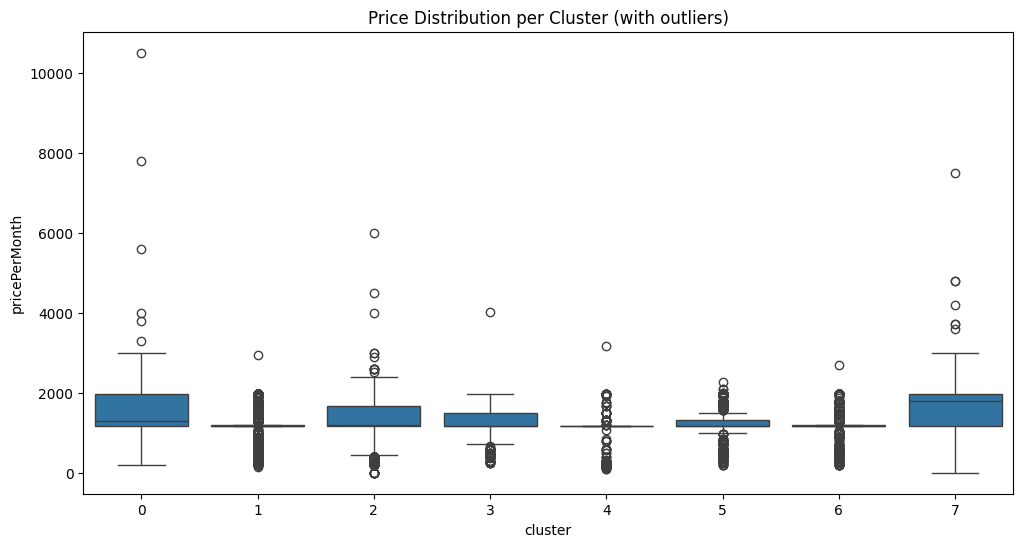

In [42]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=outfits, x="cluster", y="pricePerMonth")
plt.title("Price Distribution per Cluster (with outliers)")
plt.show()

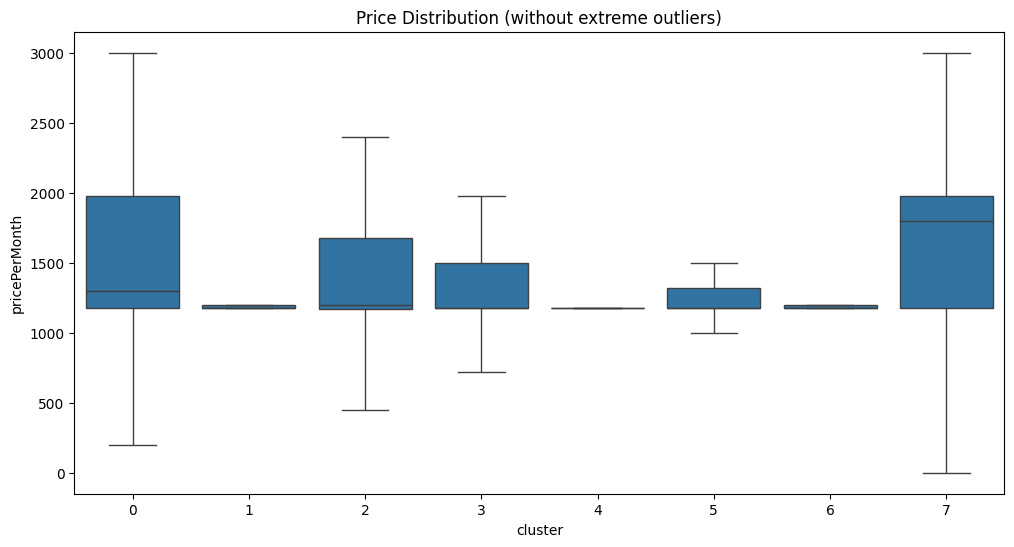

In [43]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=outfits, x="cluster", y="pricePerMonth", showfliers=False)

plt.title("Price Distribution (without extreme outliers)")
plt.show()

### Cluster revenue

In [44]:
rentals = transactions.merge(
    outfits[["id", "cluster", "pricePerWeek", "pricePerMonth"]],
    left_on="outfit.id",
    right_on="id",
    how="left"
)

Calculate rental duration/period

In [45]:
rentals["duration_days"] = (
    pd.to_datetime(rentals["rentalPeriod.end"]) -
    pd.to_datetime(rentals["rentalPeriod.start"])
).dt.days

In [46]:
rentals["revenue"] = np.where(
    rentals["duration_days"] <= 30,
    # Case A: Shorter/equal 1 month -> weekly price per started week (rounded up)
    # np.ceil(8/7) = 2.0 -> 2 * weekly price
    np.ceil(rentals["duration_days"] / 7) * rentals["pricePerWeek"],

    # Case B: Longer than 1 month -> monthly price for every started month
    # np.ceil(32/30) = 2.0 -> 2 * monthly price
    np.ceil(rentals["duration_days"] / 30) * rentals["pricePerMonth"] # not 100% accurate - i guess they would not charge for the full month if only 1 day is used, but we don't have more detailed data
)


In [47]:
cluster_revenue = rentals.groupby("cluster")["revenue"].agg([
    "sum", "mean", "count"
]).sort_values("sum", ascending=False)

cluster_revenue

,sum,mean,count
cluster,,,
2.0,71299983.0,2617.761978,27237
7.0,28520090.0,3864.510840,7380
1.0,24240702.0,2819.669885,8597
3.0,20881580.0,3174.457282,6578
5.0,11891420.0,3028.889455,3926
6.0,9086105.0,2867.183654,3169
0.0,8436395.0,2841.493769,2969
4.0,2685215.0,2438.887375,1101


### Customer revenue

In [48]:
customer_revenue = rentals.groupby("customer.id")["revenue"].sum()

Customer Cluster Affinity

In [49]:
customer_cluster_revenue = rentals.groupby(
    ["customer.id", "cluster"]
)["revenue"].sum().unstack(fill_value=0)

customer_cluster_revenue.head()

cluster,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0
customer.id,,,,,,,,
1,0.0,0.0,390.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,960.0,0.0,0.0,0.0,0.0,0.0
3,10890.0,16580.0,48030.0,3960.0,3960.0,15840.0,0.0,20640.0
4,0.0,0.0,870.0,0.0,0.0,0.0,0.0,0.0
5,700.0,0.0,600.0,0.0,0.0,0.0,0.0,0.0


Value Mapping: Cash Cow vs. High End

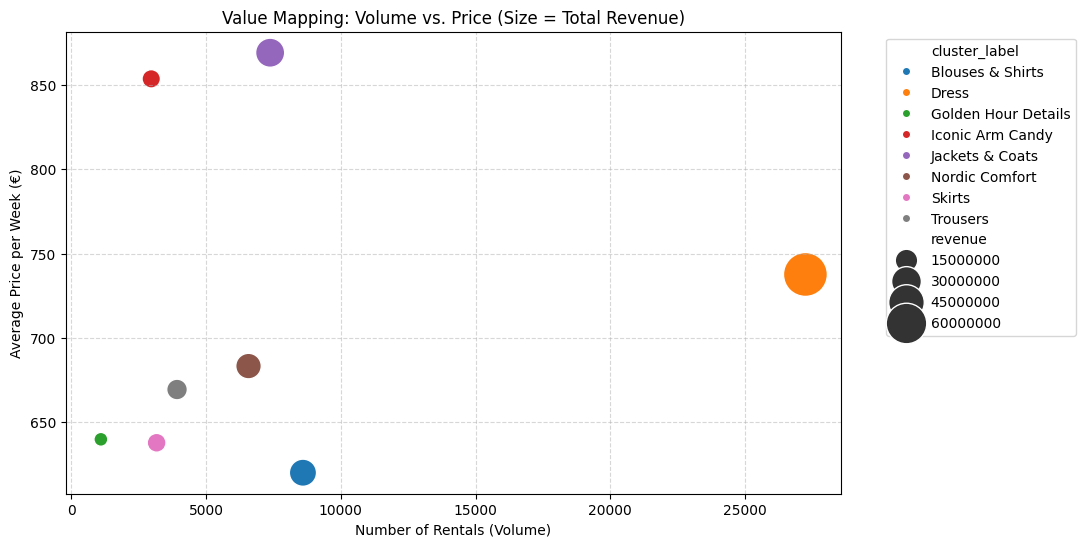

In [50]:
# Aggregate metrics per cluster
cluster_economics = rentals.merge(outfits[["id", "cluster_label"]], left_on="outfit.id", right_on="id").groupby("cluster_label").agg({
    "revenue": "sum",
    "id_x": "count", # Transaction count
    "pricePerWeek": "mean" # Avg price
}).rename(columns={"id_x": "rental_volume", "pricePerWeek": "avg_price"})

# Visualization
plt.figure(figsize=(10,6))
sns.scatterplot(data=cluster_economics, x="rental_volume", y="avg_price", size="revenue", sizes=(100, 1000), hue=cluster_economics.index)
plt.title("Value Mapping: Volume vs. Price (Size = Total Revenue)")
plt.xlabel("Number of Rentals (Volume)")
plt.ylabel("Average Price per Week (€)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

White Spaces: Utilization - Identifying where demand exceeds supply

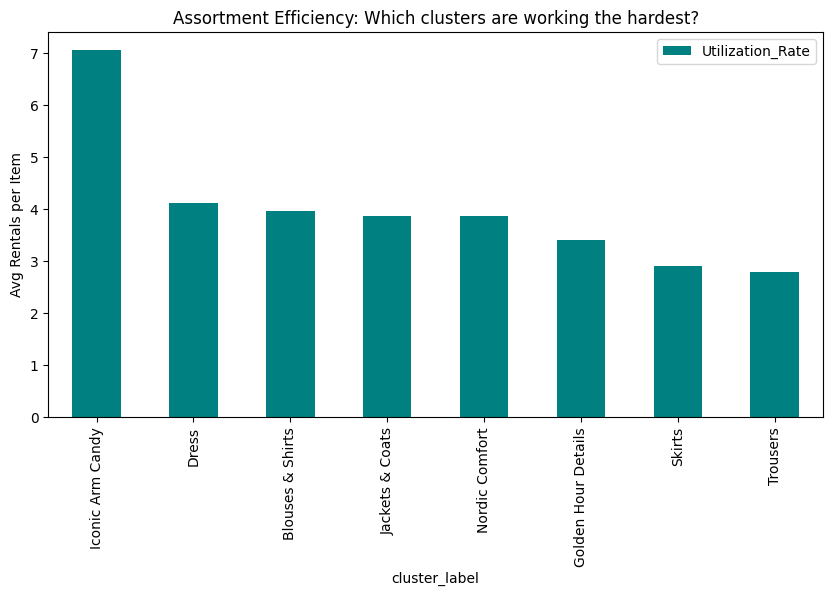

In [51]:
# 1. Count items in inventory per cluster
inventory_count = outfits.groupby("cluster_label")["id"].count()

# 2. Count rentals per cluster
rental_count = rentals.merge(outfits, left_on="outfit.id", right_on="id").groupby("cluster_label")["id_x"].count()

# 3. Calculate Utilization (Rentals per Item)
utilization = pd.DataFrame({"Inventory": inventory_count, "Rentals": rental_count})
utilization["Utilization_Rate"] = utilization["Rentals"] / utilization["Inventory"]

# Sort and visualize
utilization.sort_values("Utilization_Rate", ascending=False).plot(kind="bar", y="Utilization_Rate", color="teal", figsize=(10,5))
plt.title("Assortment Efficiency: Which clusters are working the hardest?")
plt.ylabel("Avg Rentals per Item")
plt.show()

In [52]:
utilization.sort_values("Utilization_Rate", ascending=False)

,Inventory,Rentals,Utilization_Rate
cluster_label,,,
Iconic Arm Candy,421,2969,7.052257
Dress,6623,27237,4.112487
Blouses & Shirts,2168,8597,3.965406
Jackets & Coats,1911,7380,3.861852
Nordic Comfort,1704,6578,3.860329
Golden Hour Details,323,1101,3.408669
Skirts,1090,3169,2.907339
Trousers,1409,3926,2.786373


**Results**

Bags are rented out way more per bag than other product categories (near double the catalogue average) --> there is the need to buy more bags (just 421 pieces in inventory)

Core volume driver are dresses with the most inventory and most rentals (and high utilization rate) --> shows inventory size is correct

Trousers and skirts are not heavily utilized --> customers prefer renting special occasion fits over everyday basics

Golden Hour Details are not utilized that much either and have a relatively low revenue (as seen in the plot above) 
